In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv')
print(df.shape)


(7043, 21)


In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.dtypes


,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [5]:
print ("missing values")
df.isnull().sum()

missing values


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [6]:
print("\nTotal missing:", df.isnull().sum().sum())


Total missing: 0


In [7]:
import matplotlib.pyplot as plt
churn_counts = df['Churn'].value_counts()

In [8]:
print (churn_counts)

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [9]:
print(f"\nChurn Rate: {churn_counts['Yes']/len(df)*100:.1f}%")



Churn Rate: 26.5%


<function matplotlib.pyplot.show(close=None, block=None)>

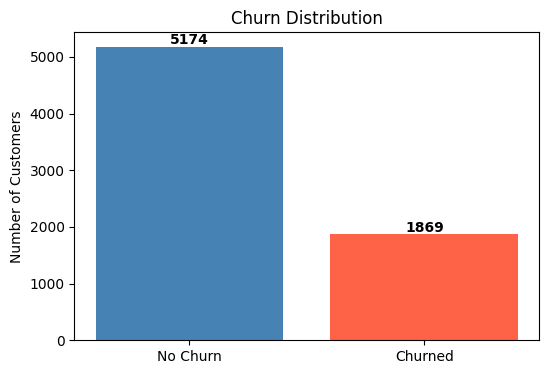

In [10]:
plt.figure(figsize=(6,4))
plt.bar(['No Churn', 'Churned'], churn_counts.values, color=['steelblue', 'tomato'])
plt.title('Churn Distribution')
plt.ylabel('Number of Customers')
for i, v in enumerate(churn_counts.values):
    plt.text(i, v + 50, str(v), ha='center', fontweight='bold')
plt.show

In [11]:
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline

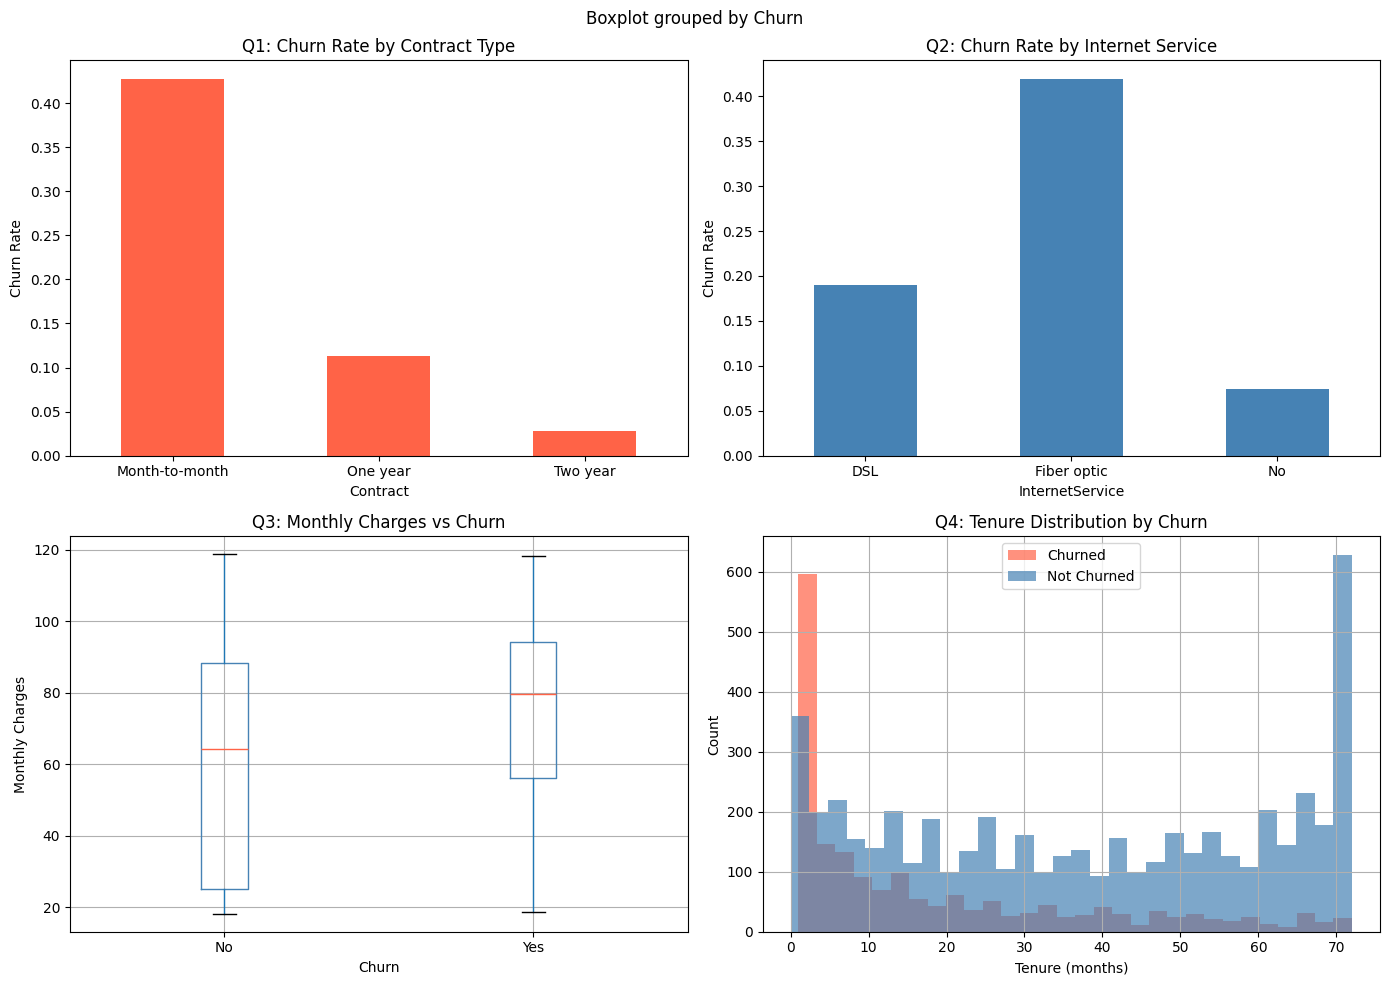

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Churn Analysis - Business Insights', fontsize=16, fontweight='bold')

# Q1 - Does contract type affect churn?
contract_churn = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack()
contract_churn['Yes'].plot(kind='bar', ax=axes[0,0], color='tomato')
axes[0,0].set_title('Q1: Churn Rate by Contract Type')
axes[0,0].set_ylabel('Churn Rate')
axes[0,0].tick_params(axis='x', rotation=0)

# Q2 - Does internet service type affect churn?
internet_churn = df.groupby('InternetService')['Churn'].value_counts(normalize=True).unstack()
internet_churn['Yes'].plot(kind='bar', ax=axes[0,1], color='steelblue')
axes[0,1].set_title('Q2: Churn Rate by Internet Service')
axes[0,1].set_ylabel('Churn Rate')
axes[0,1].tick_params(axis='x', rotation=0)

# Q3 - Does monthly charges affect churn?
df.boxplot(column='MonthlyCharges', by='Churn', ax=axes[1,0],
           boxprops=dict(color='steelblue'),
           medianprops=dict(color='tomato'))
axes[1,0].set_title('Q3: Monthly Charges vs Churn')
axes[1,0].set_xlabel('Churn')
axes[1,0].set_ylabel('Monthly Charges')

# Q4 - Does tenure affect churn?
df[df['Churn']=='Yes']['tenure'].hist(ax=axes[1,1], bins=30,
                                      color='tomato', alpha=0.7, label='Churned')
df[df['Churn']=='No']['tenure'].hist(ax=axes[1,1], bins=30,
                                     color='steelblue', alpha=0.7, label='Not Churned')
axes[1,1].set_title('Q4: Tenure Distribution by Churn')
axes[1,1].set_xlabel('Tenure (months)')
axes[1,1].set_ylabel('Count')
axes[1,1].legend()

plt.tight_layout()
plt.show()

In [13]:
# Check TotalCharges column closely
print("TotalCharges dtype:", df['TotalCharges'].dtype)
print("\nSample TotalCharges values:")
print(df['TotalCharges'].head(10).tolist())
print("\nAny spaces in TotalCharges:")
print(df[df['TotalCharges'] == ' '].shape[0], "rows with empty TotalCharges")

TotalCharges dtype: object

Sample TotalCharges values:
['29.85', '1889.5', '108.15', '1840.75', '151.65', '820.5', '1949.4', '301.9', '3046.05', '3487.95']

Any spaces in TotalCharges:
11 rows with empty TotalCharges


In [14]:
# Fix TotalCharges - convert to numeric, empty spaces become NaN, then fill with 0
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Verify fix
print("TotalCharges dtype now:", df['TotalCharges'].dtype)
print("Missing values now:", df['TotalCharges'].isnull().sum())

TotalCharges dtype now: float64
Missing values now: 0


In [15]:
# Convert Churn from Yes/No to 1/0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Verify
print("Churn values now:", df['Churn'].unique())
print("Churn distribution:")
print(df['Churn'].value_counts())

Churn values now: [0 1]
Churn distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [16]:
print("Text columns remaining:")
print(df.select_dtypes(include='object').columns.tolist())


Text columns remaining:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [17]:
# Drop customerID - useless for prediction
df = df.drop('customerID', axis=1)

# Binary columns - simple Yes/No mapping
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
binary_map = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}
df[binary_cols] = df[binary_cols].replace(binary_map)

# Multi-value columns - One Hot Encoding
multi_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity',
              'OnlineBackup', 'DeviceProtection', 'TechSupport',
              'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

# Verify
print("Shape after encoding:", df.shape)
print("\nAll columns now numeric?")
print(df.select_dtypes(include='object').columns.tolist())
print("\nNew shape:", df.shape)
print("\nFirst 3 rows:")
print(df.head(3))

Shape after encoding: (7043, 31)

All columns now numeric?
[]

New shape: (7043, 31)

First 3 rows:
   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0       0              0        1           0       1             0   
1       1              0        0           0      34             1   
2       1              0        0           0       2             1   

   PaperlessBilling  MonthlyCharges  TotalCharges  Churn  ...  \
0                 1           29.85         29.85      0  ...   
1                 0           56.95       1889.50      0  ...   
2                 1           53.85        108.15      1  ...   

   TechSupport_Yes  StreamingTV_No internet service  StreamingTV_Yes  \
0            False                            False            False   
1            False                            False            False   
2            False                            False            False   

   StreamingMovies_No internet service  StreamingMovies_Yes  \
0 

/tmp/ipykernel_744/3443055117.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[binary_cols] = df[binary_cols].replace(binary_map)


In [18]:
# Create new features based on business logic

# 1. Charge per day - how much does customer pay daily?
df['ChargePerDay'] = df['MonthlyCharges'] / (df['tenure'] + 1)

# 2. Total services subscribed - how many services does customer use?
service_cols = ['PhoneService', 'OnlineSecurity_Yes', 'OnlineBackup_Yes',
                'DeviceProtection_Yes', 'TechSupport_Yes',
                'StreamingTV_Yes', 'StreamingMovies_Yes']
df['TotalServices'] = df[service_cols].sum(axis=1)

# 3. Is new customer - tenure less than 12 months?
df['IsNewCustomer'] = (df['tenure'] < 12).astype(int)

# 4. Average monthly to total charges ratio
df['ChargeRatio'] = df['MonthlyCharges'] / (df['TotalCharges'] + 1)

# Verify
print("New shape:", df.shape)
print("\nNew features sample:")
print(df[['tenure', 'MonthlyCharges', 'ChargePerDay',
          'TotalServices', 'IsNewCustomer', 'ChargeRatio']].head())

New shape: (7043, 35)

New features sample:
   tenure  MonthlyCharges  ChargePerDay TotalServices  IsNewCustomer  \
0       1           29.85     14.925000             1              1   
1      34           56.95      1.627143             3              0   
2       2           53.85     17.950000             3              1   
3      45           42.30      0.919565             3              0   
4       2           70.70     23.566667             1              1   

   ChargeRatio  
0     0.967585  
1     0.030124  
2     0.493358  
3     0.022967  
4     0.463151  


In [19]:
print("Feature Statistics:")
print(df[['ChargePerDay', 'TotalServices',
          'IsNewCustomer', 'ChargeRatio']].describe())

print("\nNew customers in dataset:", df['IsNewCustomer'].sum())
print("Average services for churned:",
      df[df['Churn']==1]['TotalServices'].mean().round(2))
print("Average services for not churned:",
      df[df['Churn']==0]['TotalServices'].mean().round(2))

Feature Statistics:
       ChargePerDay  IsNewCustomer  ChargeRatio
count   7043.000000    7043.000000  7043.000000
mean       5.770645       0.293767     0.219382
std        8.722435       0.455519     1.880743
min        0.264384       0.000000     0.012596
25%        1.250000       0.000000     0.018091
50%        2.075926       0.000000     0.034860
75%        5.946429       1.000000     0.114266
max       80.850000       1.000000    80.850000

New customers in dataset: 2069
Average services for churned: 2.68
Average services for not churned: 3.04


In [20]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Split - 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("\nChurn rate in training:", y_train.mean().round(3))
print("Churn rate in testing:", y_test.mean().round(3))

Training set size: (5634, 34)
Testing set size: (1409, 34)

Churn rate in training: 0.265
Churn rate in testing: 0.265


In [21]:
from sklearn.preprocessing import StandardScaler
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'ChargePerDay', 'TotalServices', 'ChargeRatio']
scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])
print("Scaling done.")
print("\nMean of tenure after scaling:", round(X_train['tenure'].mean(), 4))
print("Std of tenure after scaling:",  round(X_train['tenure'].std(), 4))

Scaling done.

Mean of tenure after scaling: -0.0
Std of tenure after scaling: 1.0001


In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, f1_score

# Initialize all 3 models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss')
}

# Train and evaluate each model
results = {}
for name, model in models.items():
    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Evaluate
    auc = roc_auc_score(y_test, y_prob)
    f1 = f1_score(y_test, y_pred)

    results[name] = {'AUC-ROC': round(auc, 4), 'F1': round(f1, 4)}

    print(f"\n{'='*40}")
    print(f"Model: {name}")
    print(f"AUC-ROC: {auc:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(classification_report(y_test, y_pred,
                                target_names=['No Churn', 'Churn']))


Model: Logistic Regression
AUC-ROC: 0.8472
F1 Score: 0.5882
              precision    recall  f1-score   support

    No Churn       0.84      0.91      0.87      1035
       Churn       0.67      0.52      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409


Model: Random Forest
AUC-ROC: 0.8211
F1 Score: 0.5385
              precision    recall  f1-score   support

    No Churn       0.82      0.90      0.86      1035
       Churn       0.63      0.47      0.54       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.77      0.79      0.78      1409


Model: XGBoost
AUC-ROC: 0.8258
F1 Score: 0.5522
              precision    recall  f1-score   support

    No Churn       0.83      0.87      0.85      1035
       Churn       0.59      0.52      0.55       374

    accuracy     

In [ ]:
from sklearn.model_selection import GridSearchCV

# Parameters to try
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

# Initialize base XGBoost
xgb = XGBClassifier(random_state=42, eval_metric='logloss')

# GridSearchCV - tries all combinations
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

# Fit on training data
grid_search.fit(X_train, y_train)

# Best parameters found
print("Best Parameters:", grid_search.best_params_)
print("Best CV AUC-ROC:", round(grid_search.best_score_, 4))

# Evaluate best model on test set
best_xgb = grid_search.best_estimator_
y_pred = best_xgb.predict(X_test)
y_prob = best_xgb.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_prob)
f1 = f1_score(y_test, y_pred)

print(f"\nTuned XGBoost on Test Set:")
print(f"AUC-ROC: {auc:.4f}")
print(f"F1 Score: {f1:.4f}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits


In [ ]:
import pickle

# Save Logistic Regression model
with open('churn_model.pkl', 'wb') as f:
    pickle.dump(models['Logistic Regression'], f)

# Save the scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Model saved as churn_model.pkl")
print("Scaler saved as scaler.pkl")

In [ ]:
import pickle

# Save Logistic Regression model
with open('churn_model.pkl', 'wb') as f:
    pickle.dump(models['Logistic Regression'], f)

# Save the scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Model saved as churn_model.pkl")
print("Scaler saved as scaler.pkl")

In [ ]:
!pip install shap -q

import shap
import numpy as np
import matplotlib.pyplot as plt

print("SHAP version:", shap.__version__)


In [ ]:
# Create SHAP explainer for Logistic Regression
explainer = shap.LinearExplainer(models['Logistic Regression'],X_train,feature_perturbation="interventional")

# Calculate SHAP values for test set
shap_values = explainer.shap_values(X_test)

print("SHAP values shape:", shap_values.shape)
print("Test set shape:", X_test.shape)

In [ ]:
shap_values


In [ ]:
# Global explanation - which features matter most overall
plt.figure()
shap.summary_plot(shap_values, X_test,  feature_names=X_test.columns.tolist(),plot_type="bar",max_display=15,show=False)
plt.title("Top 15 Most Important Features For Churn Prediction")
plt.tight_layout()
plt.show()

In [ ]:
plt.figure()
# Ensure shap_values is a float array
shap_values = shap_values.astype(float)
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=X_test.columns.tolist(),
    max_display=15,
    show=False
)
plt.title("Feature Impact Direction on Churn Prediction")
plt.tight_layout()
plt.show()

In [ ]:
# Pick a customer who is predicted to churn
# Find customers with high churn probability
y_prob_all = models['Logistic Regression'].predict_proba(X_test)[:, 1]

# Find index of customer with highest churn probability
high_risk_idx = y_prob_all.argmax()

print(f"Highest risk customer index: {high_risk_idx}")
print(f"Churn probability: {y_prob_all[high_risk_idx]:.2%}")
print(f"\nActually churned: {'Yes' if y_test.iloc[high_risk_idx]==1 else 'No'}")
print(f"\nCustomer details:")
print(X_test.iloc[high_risk_idx][['tenure', 'MonthlyCharges',
                                   'TotalCharges', 'TotalServices',
                                   'ChargePerDay']])

In [ ]:
# Create explanation object for this specific customer
customer = X_test.iloc[high_risk_idx]

# Get SHAP explanation for this customer
explanation = shap.Explanation(
    values=shap_values[high_risk_idx],
    base_values=explainer.expected_value,
    data=customer.values,
    feature_names=X_test.columns.tolist()
)

# Waterfall plot
shap.plots.waterfall(explanation, max_display=10, show=False)
plt.title(f"Why Customer {high_risk_idx} Will Churn (95.98% probability)")
plt.tight_layout()
plt.show()

In [ ]:
from google.colab import files

files.download('churn_model.pkl')
files.download('scaler.pkl')